In [4]:
# Imports and Data Loading
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Tetuan City power consumption.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (52416, 9)

Columns: ['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [5]:
# EDA (Exploratory Data Analysis)
# Parse DateTime
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Row count and date range
print(f"Total records: {len(df)}")
print(f"Start date: {df['DateTime'].min()}")
print(f"End date: {df['DateTime'].max()}")

# Summary statistics
print(f"\nAvg Temp: {df['Temperature'].mean():.2f}")
print(f"Min Temp: {df['Temperature'].min():.2f}")
print(f"Max Temp: {df['Temperature'].max():.2f}")
print(f"Avg Zone 1: {df['Zone 1 Power Consumption'].mean():.2f}")
print(f"Avg Zone 2: {df['Zone 2  Power Consumption'].mean():.2f}")
print(f"Avg Zone 3: {df['Zone 3  Power Consumption'].mean():.2f}")

Total records: 52416
Start date: 2017-01-01 00:00:00
End date: 2017-12-30 23:50:00

Avg Temp: 18.81
Min Temp: 3.25
Max Temp: 40.01
Avg Zone 1: 32344.97
Avg Zone 2: 21042.51
Avg Zone 3: 17835.41


In [6]:
#  Consumption Patterns (hourly analysis + top 10 peaks + temperature ranges):
# Average consumption by hour of day
hourly = df.groupby(df['DateTime'].dt.hour)['Zone 1 Power Consumption'].mean().round(2)
print("Avg Consumption by Hour of Day:")
print(hourly.to_string())

# Top 10 peak consumption records
print("\n\nTop 10 Peak Consumption Records:")
top10 = df.nlargest(10, 'Zone 1 Power Consumption')[
    ['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption']
]
print(top10.to_string(index=False))


# Consumption by temperature range
def temp_range(t):
    if t < 15:
        return 'Cold (< 15)'
    elif t <= 25:
        return 'Mild (15-25)'
    else:
        return 'Hot (> 25)'


df['temp_range'] = df['Temperature'].apply(temp_range)
temp_analysis = df.groupby('temp_range').agg(
    avg_consumption=('Zone 1 Power Consumption', 'mean'),
    num_records=('Zone 1 Power Consumption', 'count')
).round(2).sort_values('avg_consumption', ascending=False)
print("\n\nConsumption by Temperature Range:")
print(temp_analysis)

Avg Consumption by Hour of Day:
DateTime
0     30217.24
1     27565.53
2     26292.69
3     25338.12
4     24633.58
5     23437.58
6     23203.60
7     24038.35
8     26583.26
9     29725.36
10    32566.46
11    34487.63
12    35052.52
13    35112.27
14    34643.60
15    33912.00
16    33385.20
17    34924.98
18    38846.13
19    42795.92
20    43822.59
21    42216.48
22    39068.64
23    34409.58


Top 10 Peak Consumption Records:
           DateTime  Temperature  Humidity  Wind Speed  Zone 1 Power Consumption
2017-08-07 20:20:00        27.24     78.00       4.904               52204.39512
2017-08-07 20:10:00        27.38     77.40       4.902               52146.85905
2017-08-07 20:30:00        27.24     78.70       4.907               52038.17980
2017-08-07 20:00:00        27.51     76.20       4.904               51955.07214
2017-08-08 20:00:00        26.98     84.20       4.906               51916.71476
2017-08-17 19:40:00        25.90     56.28       0.072               51820.821

In [7]:
# Feature Engineering & Train/Test Split:
# Extract temporal features
df['hour'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.dayofweek
df['month'] = df['DateTime'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

print(f"Temporal features added. Columns: {df.columns.tolist()}")
print(f"\nDate range: {df['DateTime'].min()} to {df['DateTime'].max()}")
print(df[['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption']].describe())

# Define features and target
feature_cols = [
    'Temperature', 'Humidity', 'Wind Speed',
    'general diffuse flows', 'diffuse flows',
    'hour', 'day_of_week', 'month', 'is_weekend'
]
target_col = 'Zone 1 Power Consumption'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nFeature matrix columns: {feature_cols}")


Temporal features added. Columns: ['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption', 'temp_range', 'hour', 'day_of_week', 'month', 'is_weekend']

Date range: 2017-01-01 00:00:00 to 2017-12-30 23:50:00
        Temperature      Humidity    Wind Speed  Zone 1 Power Consumption
count  52416.000000  52416.000000  52416.000000              52416.000000
mean      18.810024     68.259518      1.959489              32344.970564
std        5.815476     15.551177      2.348862               7130.562564
min        3.247000     11.340000      0.050000              13895.696200
25%       14.410000     58.310000      0.078000              26310.668692
50%       18.780000     69.860000      0.086000              32265.920340
75%       22.890000     81.400000      4.915000              37309.018185
max       40.010000     94.800000      6.483000              52204.395120

T

In [8]:
# Train the Random Forest Model & Evaluate:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"  MAE:  {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  R2:   {r2:.4f}")


Model Performance:
  MAE:  842.82
  RMSE: 1194.84
  R2:   0.9717


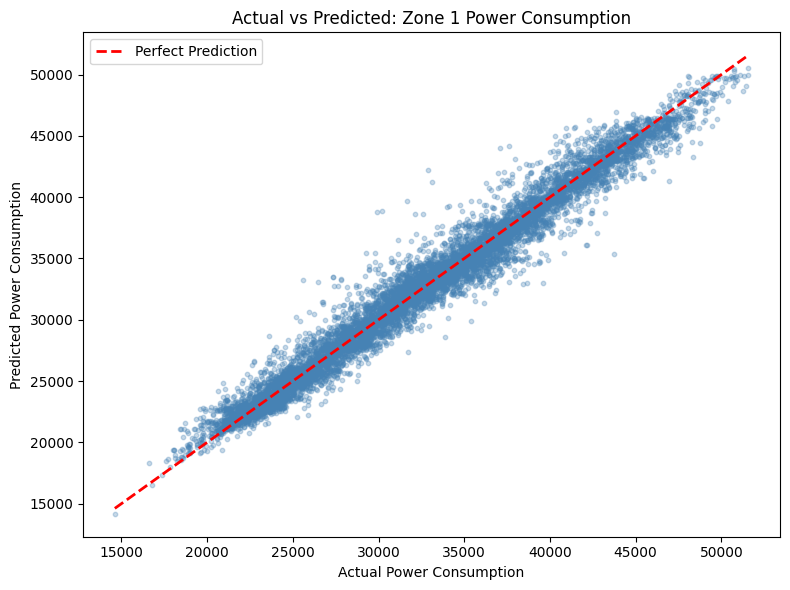

In [9]:
# Actual vs Predicted Scatter Plot:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Perfect Prediction'
)
plt.xlabel('Actual Power Consumption')
plt.ylabel('Predicted Power Consumption')
plt.title('Actual vs Predicted: Zone 1 Power Consumption')
plt.legend()
plt.tight_layout()
plt.show()

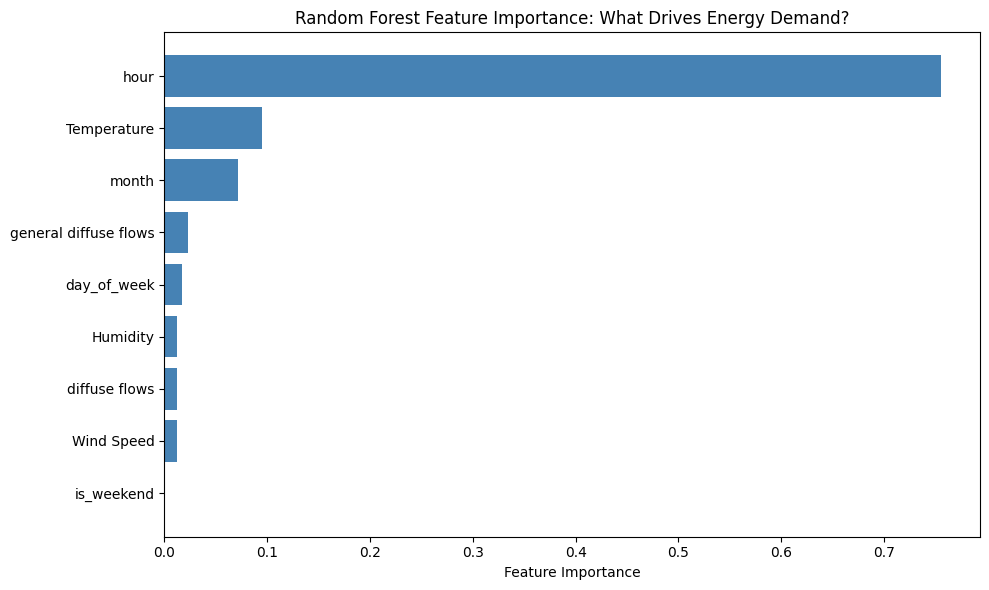


Feature Importance Ranking:
  hour.......................... 0.7554
  Temperature................... 0.0951
  month......................... 0.0716
  general diffuse flows......... 0.0231
  day_of_week................... 0.0175
  Humidity...................... 0.0123
  diffuse flows................. 0.0121
  Wind Speed.................... 0.0119
  is_weekend.................... 0.0010


In [10]:
# Feature Importance & Business Recommendations
# Feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance: What Drives Energy Demand?')
plt.tight_layout()
plt.show()

# Print ranked importance
print("\nFeature Importance Ranking:")
for _, row in feature_importance_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']:.<30} {row['Importance']:.4f}")

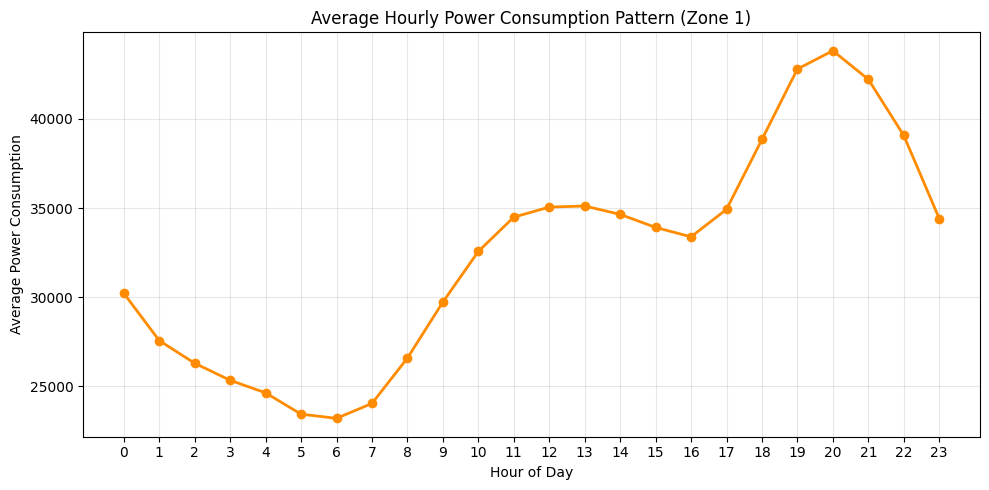

In [11]:
# Hourly Consumption Pattern Plot
# Calculate average consumption for each hour across all days
hourly_avg = df.groupby('hour')[target_col].mean()

# Plot the daily demand curve
plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, color='darkorange')
plt.xlabel('Hour of Day')
plt.ylabel('Average Power Consumption')
plt.title('Average Hourly Power Consumption Pattern (Zone 1)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Business Recommendations
print("=" * 60)
print("BUSINESS RECOMMENDATIONS FOR DEMAND RESPONSE PROGRAM")
print("=" * 60)

# 1. Peak demand hours
peak_hours = hourly_avg.nlargest(5).index.tolist()
print(f"\n1. PEAK DEMAND HOURS: {sorted(peak_hours)}")
print(f"   Schedule demand response events during hours")
print(f"   {sorted(peak_hours)} when consumption is highest.")

# 2. Temperature trigger
temp_threshold = df['Temperature'].quantile(0.9)
high_temp_mask = df['Temperature'] > temp_threshold
avg_high_temp = df.loc[high_temp_mask, target_col].mean()
avg_normal = df.loc[~high_temp_mask, target_col].mean()
pct_increase = ((avg_high_temp - avg_normal) / avg_normal) * 100

print(f"\n2. TEMPERATURE TRIGGER: {temp_threshold:.1f} degrees")
print(f"   When temperature exceeds {temp_threshold:.1f}, consumption")
print(f"   increases by {pct_increase:.1f}% on average.")
print(f"   Pre-trigger demand response when forecasted temperature")
print(f"   exceeds this threshold.")

# 3. Weekday vs weekend
weekend_avg = df[df['is_weekend'] == 1][target_col].mean()
weekday_avg = df[df['is_weekend'] == 0][target_col].mean()
higher_period = 'weekdays' if weekday_avg > weekend_avg else 'weekends'

print(f"\n3. WEEKDAY vs WEEKEND CONSUMPTION:")
print(f"   Weekday average: {weekday_avg:,.0f}")
print(f"   Weekend average: {weekend_avg:,.0f}")
print(f"   Focus demand response resources on {higher_period}.")

# 4. Model confidence
print(f"\n4. MODEL CONFIDENCE: R2 = {r2:.4f}")
print(f"   The model explains {r2 * 100:.1f}% of consumption variance.")
print(f"   Primary drivers: {feature_importance_df.iloc[0]['Feature']}")
print(f"   and {feature_importance_df.iloc[1]['Feature']}.")
print(f"\n" + "=" * 60)

BUSINESS RECOMMENDATIONS FOR DEMAND RESPONSE PROGRAM

1. PEAK DEMAND HOURS: [18, 19, 20, 21, 22]
   Schedule demand response events during hours
   [18, 19, 20, 21, 22] when consumption is highest.

2. TEMPERATURE TRIGGER: 26.4 degrees
   When temperature exceeds 26.4, consumption
   increases by 21.3% on average.
   Pre-trigger demand response when forecasted temperature
   exceeds this threshold.

3. WEEKDAY vs WEEKEND CONSUMPTION:
   Weekday average: 32,676
   Weekend average: 31,517
   Focus demand response resources on weekdays.

4. MODEL CONFIDENCE: R2 = 0.9717
   The model explains 97.2% of consumption variance.
   Primary drivers: is_weekend
   and Wind Speed.



In [13]:
# Fix: sort descending to get top drivers
top_features = feature_importance_df.sort_values('Importance', ascending=False)
print(f"Primary drivers: {top_features.iloc[0]['Feature']}")
print(f"and {top_features.iloc[1]['Feature']}.")

Primary drivers: hour
and Temperature.


In [14]:
# Section Mission:
# Define Peak Labels
# Define "peak" threshold at 75th percentile of Zone 1 consumption
peak_threshold = df['Zone 1 Power Consumption'].quantile(0.75)
df['is_peak'] = (df['Zone 1 Power Consumption'] > peak_threshold).astype(int)

print(f"Peak threshold (75th percentile): {peak_threshold:,.0f}")
print(f"\nClass distribution:")
print(df['is_peak'].value_counts())
print(f"\nPeak hours: {df['is_peak'].sum()} ({df['is_peak'].mean() * 100:.1f}%)")

Peak threshold (75th percentile): 37,309

Class distribution:
is_peak
0    39312
1    13104
Name: count, dtype: int64

Peak hours: 13104 (25.0%)


In [15]:
# Train Classifier & Evaluate:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Use the same features as the regression model
X_class = df[feature_cols]
y_class = df['is_peak']

# Split into train/test sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_classifier.fit(X_train_c, y_train_c)

# Generate predictions and print classification report
y_pred_c = rf_classifier.predict(X_test_c)
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Off-Peak', 'Peak']))

Classification Report:
              precision    recall  f1-score   support

    Off-Peak       0.98      0.98      0.98      7822
        Peak       0.95      0.93      0.94      2662

    accuracy                           0.97     10484
   macro avg       0.96      0.96      0.96     10484
weighted avg       0.97      0.97      0.97     10484



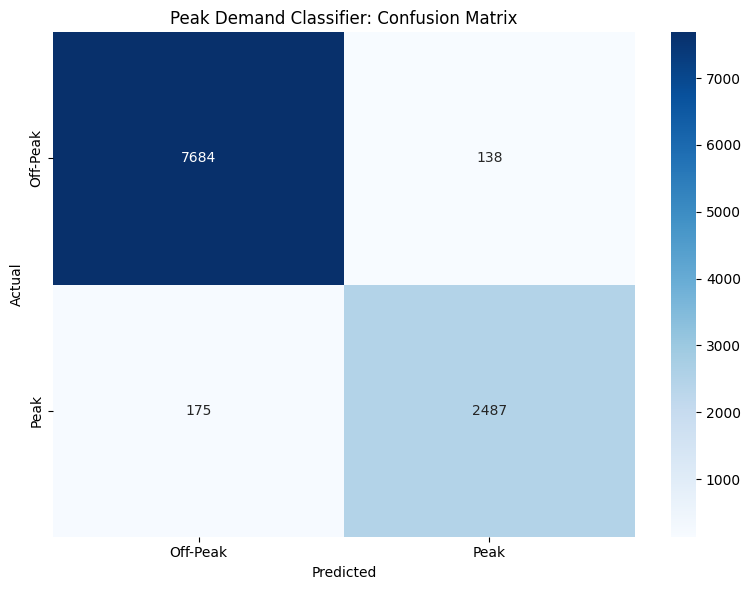


False Negative Rate: 6.6%
This means 6.6% of actual peak hours are missed by the model.

BUSINESS INTERPRETATION:
A false negative means the model predicts 'off-peak' when demand is
actually at peak levels. For a utility, this means failing to trigger
demand response in time, risking grid strain or expensive spot purchases.

A false positive triggers demand response unnecessarily, which costs
money but does not risk grid reliability. In utility operations,
false negatives are MORE costly than false positives.


In [16]:
# Confusion Matrix
# Create confusion matrix heatmap
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Off-Peak', 'Peak'],
    yticklabels=['Off-Peak', 'Peak']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Peak Demand Classifier: Confusion Matrix')
plt.tight_layout()
plt.show()

# Calculate and interpret false negative rate
false_negatives = cm[1][0]
total_actual_peak = cm[1][0] + cm[1][1]
fn_rate = false_negatives / total_actual_peak * 100

print(f"\nFalse Negative Rate: {fn_rate:.1f}%")
print(f"This means {fn_rate:.1f}% of actual peak hours are missed by the model.")
print(f"\nBUSINESS INTERPRETATION:")
print(f"A false negative means the model predicts 'off-peak' when demand is")
print(f"actually at peak levels. For a utility, this means failing to trigger")
print(f"demand response in time, risking grid strain or expensive spot purchases.")
print(f"\nA false positive triggers demand response unnecessarily, which costs")
print(f"money but does not risk grid reliability. In utility operations,")
print(f"false negatives are MORE costly than false positives.")